# FE vs ROM comparison

This notebook compares the full FE model against the modal-reduced helper-level ROM in both frequency domain and time domain.

The notebook keeps the full-order assembly and the ROM solver separate:
- full system: `PiezoBeamFE` + `build_ode_system(...)`
- reduced system: `build_fe_rom_system(...)` + `solve_ivp_rom(...)`

In [18]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import importlib

def find_project_root(start: Path) -> Path:
    """Find project root that contains the Modeling package."""
    for p in [start, *start.parents]:
        if (p / "Modeling").exists():
            return p
    raise RuntimeError("Could not locate project root containing 'Modeling'.")


project_root = find_project_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from Modeling.models import FE_helpers
import Modeling.models.FE3 as FE_module
importlib.reload(FE_helpers)
importlib.reload(FE_module)
FE = FE_module
from Modeling.models import common_imports 
importlib.reload(common_imports)
from Modeling.models.common_imports import *
solve_newmark = FE_helpers.solve_newmark
frf_sweep = FE_helpers.frf_sweep
build_fe_rom_system_from_ode = FE_helpers.build_fe_rom_system_from_ode
solve_ivp_rom = FE_helpers.solve_ivp_rom
frf_sweep_fe_rom = FE_helpers.frf_sweep_fe_rom

K_i = 1800
K_p = 0.0025
K_c = 0
R_c = 1e3
t_end = 0.5
f0 = 1000
f1 = 3000
dt = 1 / f1 / 20


def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
    return A_exc * np.sin(2 * np.pi * (f0 + t * (f1 - f0) / t_end) * t)


params_fe = PiezoBeamParams(
    hp=0.252e-3,
    hs=0.51e-3,
    d31=-1.48e-10,
    eps_r=1700,
)
params_fe.zeta_p = 0.0151 * 8
params_fe.zeta_q = 0.0392 * 10


def plot_freq_compare(freq_hz, full_resp, rom_resp, dof_index=0, title="Frequency-domain comparison"):
    plt.figure(figsize=(8, 4))
    # plt.semilogy(freq_hz, np.abs(full_resp[:, dof_index]), label="Full FE")
    plt.plot(freq_hz, np.abs(rom_resp[:, dof_index]), "--", label="ROM")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("|Response|")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()



def plot_time_compare(t_full, u_full, t_rom, u_rom, dof_index=0, title="Time-domain comparison"):
    plt.figure(figsize=(8, 4))
    plt.plot(t_full, u_full[:, dof_index], label="Full FE")
    plt.plot(t_rom, u_rom[:, dof_index], "--", label="ROM")
    plt.xlabel("Time [s]")
    plt.ylabel("Response")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()


# Build the full FE model and the FE ROM from the assembled full ODE.
fe = FE.PiezoBeamFE(params_fe)
ode_full = fe.build_ode_system(j_exc=[30], R_c=R_c, K_p=K_p, K_i=K_i, K_c=K_c, v_exc=v_exc)
rom = build_fe_rom_system_from_ode(ode_full, n_modes_max=24, freq_max=5000.0)

omega_vec = np.linspace(1.0, 2 * np.pi * 5000.0, 400)


ROM FRF sweep: 100%|██████████| 400/400 [00:00<00:00, 3095.08it/s]


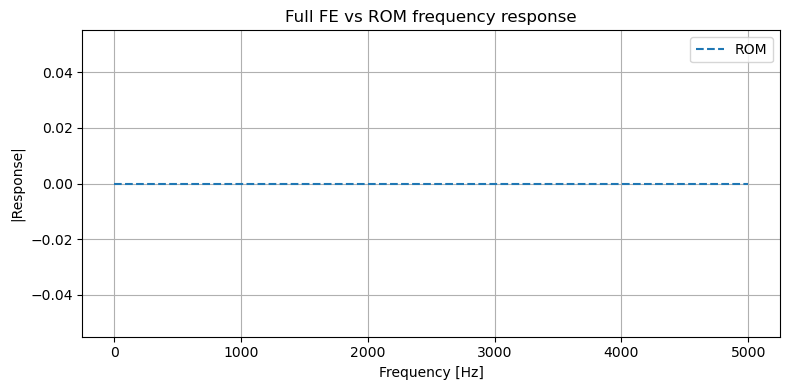

In [19]:
# Frequency-domain comparison
frf_full = frf_sweep(ode_full, omega_vec)
frf_rom = frf_sweep_fe_rom(rom, omega_vec)

freq_hz = omega_vec / (2 * np.pi)
plot_freq_compare(freq_hz, frf_full["u"], frf_rom["u"], dof_index=0, title="Full FE vs ROM frequency response")


Newmark Integration: 100%|██████████| 30000/30000 [01:05<00:00, 455.10step/s]


Relative L2 error on first mechanical DOF: 7.987e-01


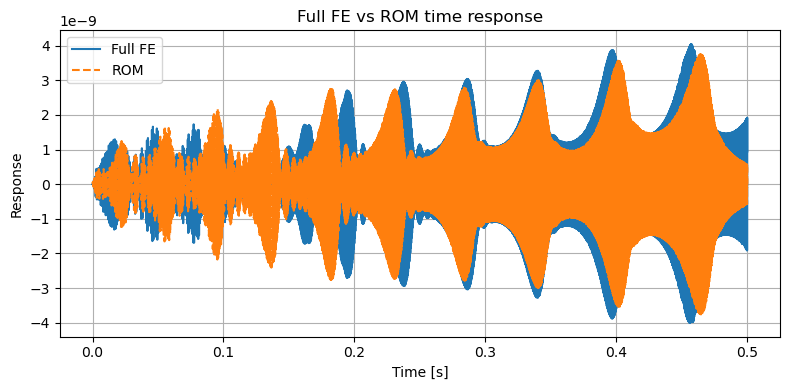

In [20]:

# Time-domain comparison
full_time = solve_newmark(ode_full, dt=dt, t_end=t_end, x0=None, x_dot0=None, do_spectral=False)
rom_time = solve_ivp_rom(rom, dt=dt, t_end=t_end, do_spectral=False)

plot_time_compare(full_time["t"], full_time["u"], rom_time["t"], rom_time["u"], dof_index=0, title="Full FE vs ROM time response")

# Optional quantitative errors on the first mechanical DOF
full_u0 = full_time["u"][:, 0]
rom_u0 = np.interp(full_time["t"], rom_time["t"], rom_time["u"][:, 0])
rel_l2_err = np.linalg.norm(full_u0 - rom_u0) / max(np.linalg.norm(full_u0), 1e-12)
print(f"Relative L2 error on first mechanical DOF: {rel_l2_err:.3e}")
